# Notebook 03 — Basis Sets

**MOLEKUL | Phases 3 & 9**

---

Every calculation in quantum chemistry is an approximation — and the first, fundamental
approximation is the choice of **basis set**: a finite set of functions used to represent
the molecular orbitals.

MOLEKUL implements three basis sets that span three decades of development:

| Basis | Year | Type | H₂O functions |
|-------|------|------|---------------|
| STO-3G | 1969 | Minimal | 7 |
| 6-31G* | 1972–73 | Split-valence + polarisation | 19 |
| cc-pVDZ | 1989 | Correlation-consistent | 25 |

*(MOLEKUL uses 6 Cartesian d-functions per d-shell, so cc-pVDZ water has 25, not
the 24 you would count with 5 spherical-harmonic d-functions.)*

**What you will learn:**
1. How contracted Gaussian basis sets are constructed.
2. Why we need more than one function per orbital (split-valence).
3. Why we add polarisation functions for accurate geometries and energies.
4. What "correlation-consistent" means and when it matters.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.basis_631gstar import G631Star
from molekul.basis_ccpvdz import ccpVDZ
from molekul.basis import Shell
from molekul.constants import ANGSTROM_TO_BOHR

h2o = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.1173),
        Atom.from_angstrom("H",  0.7572,  0.0000, -0.4692),
        Atom.from_angstrom("H", -0.7572,  0.0000, -0.4692),
    ],
    name="water",
)
print("Molecule ready.")

Molecule ready.


## 1. What a basis set is

A **basis set** assigns a list of `Shell` objects to each element symbol.
A `Shell` carries:
- `l` — angular momentum ($0 = s$, $1 = p$, $2 = d$).
- `exponents` — Gaussian exponents $\alpha_k$.
- `coefficients` — contraction coefficients $c_k$.

The contracted basis function centred on atom $A$ is:
$$\phi_\mu(\mathbf{r}) = N_{\text{contracted}}\sum_k c_k N_k\,(x-A_x)^{l_x}(y-A_y)^{l_y}(z-A_z)^{l_z}\,e^{-\alpha_k|\mathbf{r}-\mathbf{A}|^2}$$

Each p-shell contributes 3 basis functions (px, py, pz), each d-shell contributes 6
(Cartesian: xx, yy, zz, xy, xz, yz).

In [2]:
sto3g = STO3G

print("STO-3G shells for oxygen:")
for i, shell in enumerate(sto3g.shells_by_element["O"]):
    l_label = {0: "s", 1: "p", 2: "d"}[shell.l]
    print(f"  Shell {i} (l={shell.l}, {l_label}):")
    for exp, coef in zip(shell.exponents, shell.coefficients):
        print(f"    alpha={exp:10.5f}   c={coef:+.7f}")

STO-3G shells for oxygen:
  Shell 0 (l=0, s):
    alpha= 130.70932   c=+0.1543290
    alpha=  23.80886   c=+0.5353281
    alpha=   6.44361   c=+0.4446345
  Shell 1 (l=0, s):
    alpha=   5.03315   c=-0.0999672
    alpha=   1.16960   c=+0.3995128
    alpha=   0.38039   c=+0.7001155
  Shell 2 (l=1, p):
    alpha=   5.03315   c=+0.1559163
    alpha=   1.16960   c=+0.6076837
    alpha=   0.38039   c=+0.3919574


In [3]:
bases = [("STO-3G", STO3G), ("6-31G*", G631Star), ("cc-pVDZ", ccpVDZ)]

print(f"{'Basis':10s}  {'H₂O N':>7}  {'N₂ N':>6}  {'description'}")
n2 = Molecule(
    atoms=[Atom.from_angstrom("N", 0.0, 0.0, 0.549),
           Atom.from_angstrom("N", 0.0, 0.0, -0.549)]
)
for name, b in bases:
    n_h2o = len(b.basis_functions(h2o))
    n_n2  = len(b.basis_functions(n2))
    print(f"{name:10s}  {n_h2o:>7d}  {n_n2:>6d}")

Basis         H₂O N    N₂ N  description
STO-3G            7      10
6-31G*           19      30
cc-pVDZ          25      30


## 2. STO-3G — the minimal basis

STO-3G (1969, Hehre, Stewart, Pople) fits each Slater-type orbital (STO) with exactly
3 Gaussians. STOs have the physically correct $e^{-\zeta r}$ decay but no closed-form
multi-centre integrals. Gaussians approximate their shape while enabling cheap integrals.

**Minimal** means: one contracted function per occupied atomic orbital.
- H: 1s → 1 function
- O: 1s, 2s, 2px, 2py, 2pz → 5 functions
- Water: 7 total

**Limitation:** The inner and outer parts of a valence orbital both use the same
contracted function. The orbital cannot breathe (expand or contract) in response
to the molecular environment.

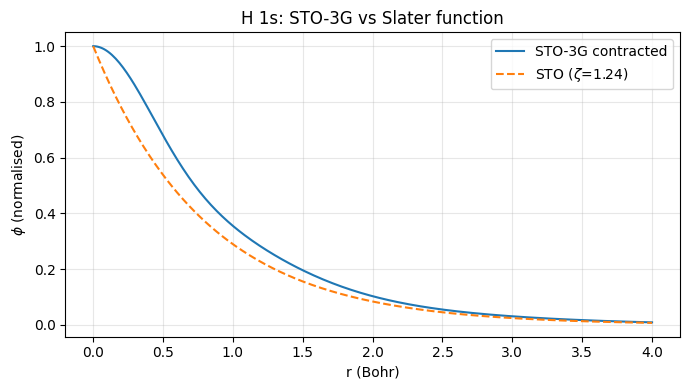

In [4]:
# Visualise the STO-3G 1s hydrogen contracted function vs the STO it approximates
r = np.linspace(0, 4, 300)  # Bohr

shell_H = STO3G.shells_by_element["H"][0]  # the 1s shell
from molekul.basis import norm_primitive

# Contracted Gaussian: sum of 3 primitives (evaluated on z-axis, x=y=0)
coords = np.zeros((len(r), 3))
coords[:, 2] = r
A = np.zeros(3)

g_contracted = np.zeros(len(r))
for alpha, c in zip(shell_H.exponents, shell_H.coefficients):
    N = norm_primitive(alpha, 0, 0, 0)
    g_contracted += c * N * np.exp(-alpha * r**2)

# STO (exact): phi_1s(r) = (zeta^3/pi)^0.5 exp(-zeta*r), zeta=1.0 for H
zeta = 1.24  # STO-3G fitted zeta for H
sto  = (zeta**3 / np.pi)**0.5 * np.exp(-zeta * r)

# Normalise both to max=1 for visual comparison
g_contracted /= g_contracted.max()
sto /= sto.max()

plt.figure(figsize=(7, 4))
plt.plot(r, g_contracted, label="STO-3G contracted")
plt.plot(r, sto, "--", label=f"STO ($\\zeta$={zeta})")
plt.xlabel("r (Bohr)")
plt.ylabel("$\\phi$ (normalised)")
plt.title("H 1s: STO-3G vs Slater function")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 6-31G* — split-valence with polarisation

**Split-valence:** The valence shell is split into two contracted functions —
one tight (inner) and one diffuse (outer). The SCF can mix them with different
coefficients, letting the orbital adjust its size.

The notation `6-31G` means:
- Core orbitals: 6 primitives contracted to 1 function.
- Valence: 3 primitives → 1 contracted + 1 single-primitive diffuse.

**Polarisation (`*`):** adds d-functions to non-hydrogen atoms. These have higher
angular momentum than the occupied valence orbitals and allow the electron density
to polarise (distort) in the molecular field. Critical for accurate geometries and dipoles.

The `*` notation means d-functions on heavy atoms only.
`**` would add p-functions on hydrogen too.

6-31G* for oxygen:
- Core 1s: (6s) → [1s]
- Valence: (3s, 3p) → [1s, 1p] inner + [1s, 1p] outer
- Polarisation: [1d]
- Total on O: 1+1+1 s + (1+1)×3 p + 6 d = **15 functions**

In [5]:
basis631 = G631Star
print("6-31G* shells for oxygen:")
for i, shell in enumerate(basis631.shells_by_element["O"]):
    l_label = {0: "s", 1: "p", 2: "d"}[shell.l]
    n_prim = len(shell.exponents)
    print(f"  Shell {i:2d} (l={shell.l}, {l_label}, {n_prim} primitives): "
          f"alpha_min={min(shell.exponents):.4f}  alpha_max={max(shell.exponents):.4f}")

6-31G* shells for oxygen:
  Shell  0 (l=0, s, 6 primitives): alpha_min=5.7996  alpha_max=5484.6717
  Shell  1 (l=0, s, 3 primitives): alpha_min=1.0138  alpha_max=15.5396
  Shell  2 (l=1, p, 3 primitives): alpha_min=1.0138  alpha_max=15.5396
  Shell  3 (l=0, s, 1 primitives): alpha_min=0.2700  alpha_max=0.2700
  Shell  4 (l=1, p, 1 primitives): alpha_min=0.2700  alpha_max=0.2700
  Shell  5 (l=2, d, 1 primitives): alpha_min=0.8000  alpha_max=0.8000


## 4. cc-pVDZ — correlation-consistent

Dunning's correlation-consistent basis sets (1989) are designed so that each
additional angular momentum shell adds a roughly equal increment of correlation energy.

- **cc-pVDZ** (double-zeta): 1 core + 2 valence + 1 polarisation.
- **cc-pVTZ** (triple-zeta): extends to f-functions on heavy atoms.
- **cc-pVQZ**, **cc-pV5Z**, ...: systematic convergence to the CBS limit.

The key property: energies computed with cc-pVXZ (X = D, T, Q, 5, ...) converge
smoothly and can be extrapolated to the complete basis set (CBS) limit.
This makes them the standard choice for correlated calculations (MP2, CCSD, CCSD(T)).

**Contrast with Pople sets:** 6-31G* was designed for HF geometry optimisation.
It is not designed for systematic convergence — going from 6-31G* to 6-311G** does
not guarantee a predictable improvement in correlation energy.

In [6]:
ccpvdz = ccpVDZ
print("cc-pVDZ shells for oxygen:")
for i, shell in enumerate(ccpvdz.shells_by_element["O"]):
    l_label = {0: "s", 1: "p", 2: "d"}[shell.l]
    n_prim = len(shell.exponents)
    print(f"  Shell {i:2d} (l={shell.l}, {l_label}, {n_prim} primitives)")

cc-pVDZ shells for oxygen:
  Shell  0 (l=0, s, 8 primitives)
  Shell  1 (l=0, s, 8 primitives)
  Shell  2 (l=0, s, 1 primitives)
  Shell  3 (l=1, p, 3 primitives)
  Shell  4 (l=1, p, 1 primitives)
  Shell  5 (l=2, d, 1 primitives)


## 5. Basis set effect on energy: H₂O RHF comparison

Let us compute the RHF energy of water with all three basis sets to see
the systematic improvement. A larger basis always gives a lower (better) HF energy
— this is the **variational principle**.

*(This cell runs RHF SCF — see Notebook 04 for details on the algorithm.)*

In [7]:
from molekul.rhf import rhf_scf
from molekul.constants import HARTREE_TO_KCAL_MOL

results = {}
for name, b in bases:
    res = rhf_scf(h2o, b)
    results[name] = res
    status = "✓" if res.converged else "✗"
    print(f"{name:10s}: E = {res.energy_total:12.6f} Ha  ({res.n_iter} iter) {status}")

# Energy lowering relative to STO-3G
E_ref = results["STO-3G"].energy_total
print("\nEnergy lowering vs STO-3G:")
for name, res in results.items():
    delta = (res.energy_total - E_ref) * HARTREE_TO_KCAL_MOL
    print(f"  {name}: {delta:+.2f} kcal/mol")

STO-3G    : E =   -74.963023 Ha  (9 iter) ✓


6-31G*    : E =   -76.010505 Ha  (15 iter) ✓


cc-pVDZ   : E =   -76.027113 Ha  (16 iter) ✓

Energy lowering vs STO-3G:
  STO-3G: +0.00 kcal/mol
  6-31G*: -657.30 kcal/mol
  cc-pVDZ: -667.73 kcal/mol


## 6. Orbital energy levels across basis sets

The HOMO and LUMO energies differ between basis sets — a larger basis gives a more
accurate HOMO (ionisation potential by Koopmans' theorem) and brings the LUMO
closer to the true electron affinity.

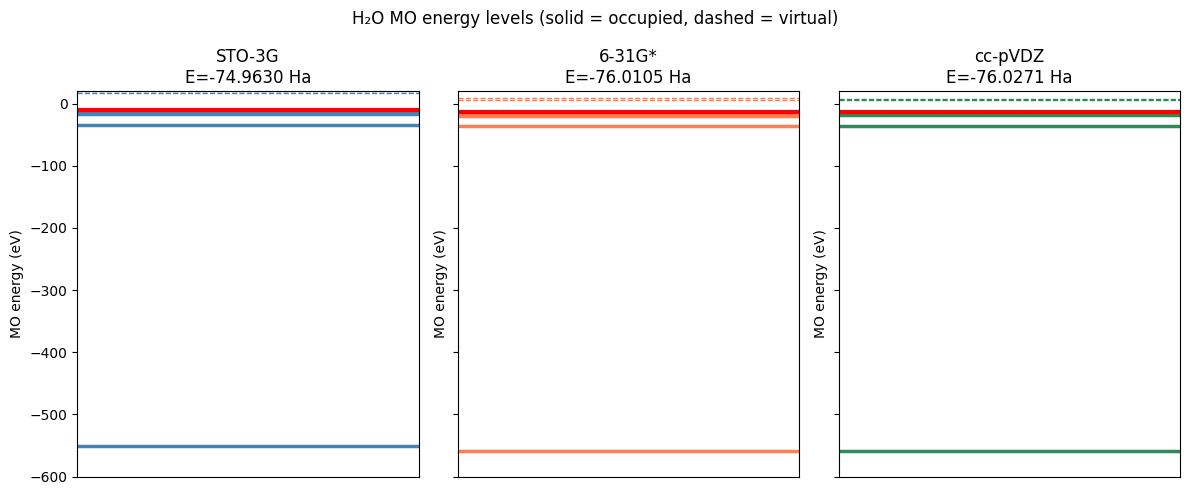

HOMO energies (Koopmans IP):
  STO-3G: -10.646 eV  (exp. IP ≈ -12.6 eV)
  6-31G*: -13.548 eV  (exp. IP ≈ -12.6 eV)
  cc-pVDZ: -13.428 eV  (exp. IP ≈ -12.6 eV)


In [8]:
from molekul.constants import HARTREE_TO_EV

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
colors = ["steelblue", "coral", "seagreen"]

for ax, (name, res), color in zip(axes, results.items(), colors):
    eps = res.mo_energies * HARTREE_TO_EV
    n_occ = h2o.n_electrons // 2
    for i, e in enumerate(eps):
        lw = 2.5 if i < n_occ else 1.0
        ls = "-" if i < n_occ else "--"
        ax.axhline(e, lw=lw, ls=ls, color=color)
    ax.axhline(eps[n_occ - 1], lw=3, color="red", label="HOMO")
    ax.set_title(f"{name}\nE={res.energy_total:.4f} Ha")
    ax.set_ylabel("MO energy (eV)")
    ax.set_ylim(-600, 20)
    ax.set_xticks([])

plt.suptitle("H₂O MO energy levels (solid = occupied, dashed = virtual)")
plt.tight_layout()
plt.show()

print("HOMO energies (Koopmans IP):")
for name, res in results.items():
    n_occ = h2o.n_electrons // 2
    homo_ev = res.mo_energies[n_occ - 1] * HARTREE_TO_EV
    print(f"  {name}: {homo_ev:.3f} eV  (exp. IP ≈ -12.6 eV)")

## 7. Choosing a basis set in practice

| Purpose | Recommended minimum |
|---------|--------------------|
| Qualitative geometry | STO-3G |
| Geometry optimisation | 6-31G* or cc-pVDZ |
| Relative energies (thermochemistry) | cc-pVTZ |
| Correlated methods (MP2, CCSD) | cc-pVDZ as starting point; extrapolate to CBS |
| Excited states | aug-cc-pVDZ (diffuse functions needed) |

The key rule: **always check that your result is converged with respect to basis set size**
by repeating the calculation with a larger basis and comparing. If the difference is
larger than your target accuracy, you need a bigger basis.

MOLEKUL currently implements STO-3G, 6-31G\*, and cc-pVDZ — all three are used throughout
the phase benchmarks to demonstrate this convergence behaviour.

---

## Exercises

**1.** Count the basis functions for N₂ and CH₄ in each basis set by hand (before running the
code). Confirm with `len(basis.basis_functions(mol))`.

**2.** Plot the radial profile of the STO-3G O 2s contracted function and compare it to the
O 1s function. Why is the 2s radial profile more oscillatory?

**3.** Compute the RHF energy of N₂ in all three basis sets. What is the energy lowering
(in kcal/mol) going from STO-3G → 6-31G* → cc-pVDZ?

**4.** The variational principle guarantees that a larger basis always gives a lower (better)
HF energy. Verify this for H₂ by comparing all three basis sets.

**5.** (Advanced) The 6-31G* d-exponent for oxygen is a single Gaussian. How does the choice
of this exponent affect the energy? Modify the exponent (±50%) and rerun the HF calculation.

---

## Summary

| Basis | Key feature | Limitation |
|-------|------------|------------|
| STO-3G | Minimal: 1 function/orbital | No orbital flexibility; poor energetics |
| 6-31G* | Split-valence + polarisation | Not designed for systematic CBS extrapolation |
| cc-pVDZ | Correlation-consistent | Larger; should be paired with cc-pVTZ for extrapolation |

Basis set choice is the first source of systematic error in any calculation.
The second is the treatment of electron correlation — the subject of Notebooks 07 and 08.